# Entanglement entropy and entanglement spectrum
We will now see how to compute the entanglement entropy of a region of a ground state, and its
entanglement spectrum, with `h.get_entanglement_entropy()` and `h.get_entanglement_spectrum()`.
The ground state of a non-interacting or mean-field Hamiltonian is a Slater determinant, and for a
Slater determinant the reduced density matrix of a region $A$ is completely fixed by the
correlation matrix $C_{ij} = \langle c_i^\dagger c_j\rangle$ restricted to $A$. Its eigenvalues
$\zeta_n\in[0,1]$ give

$$
S = -\sum_n \left[ \zeta_n \ln \zeta_n + (1-\zeta_n)\ln(1-\zeta_n)\right],
\qquad
\xi_n = \ln\frac{1-\zeta_n}{\zeta_n}
$$

the entanglement entropy and the single-particle entanglement spectrum, so only a matrix the size
of the region is ever diagonalized. A periodic Hamiltonian is folded into a ring of `nsuper` unit
cells, so the region has two entanglement boundaries. For a two-dimensional Hamiltonian the
momentum parallel to the cut is still a good quantum number, and $\xi_n(k_\parallel)$ is the
Li-Haldane entanglement spectrum: for a Chern insulator its in-gap branches flow across $\xi=0$,
$|C|$ chiral branches per boundary, mirroring the edge states of the same model, although no ribbon
and no open boundary is ever built.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry


### Li-Haldane entanglement spectrum of a Chern insulator
We compute $\xi_n(k_\parallel)$ for the Haldane model and for the honeycomb lattice gapped by a
sublattice imbalance, and show each as a density of entanglement levels, every level broadened into
a Lorentzian. For the Chern insulator two branches cross $\xi=0$, one per boundary of the region,
with opposite chirality; the trivial insulator has a spectrum that never comes close to zero.

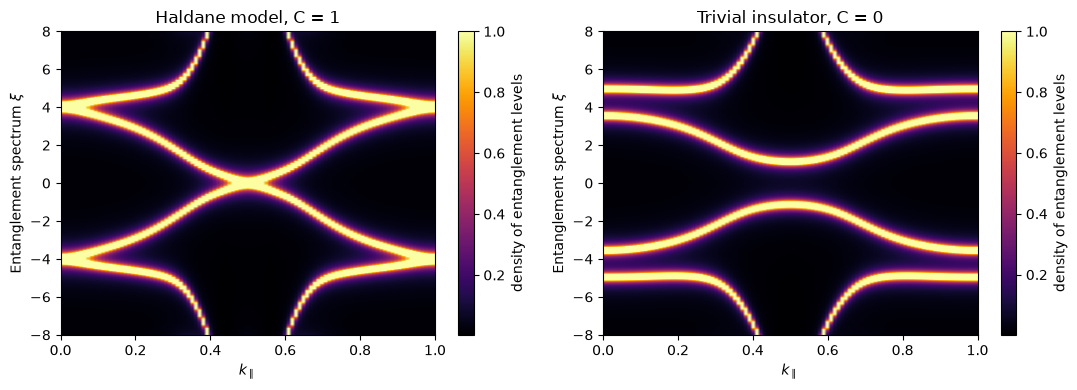

In [2]:
g = geometry.honeycomb_lattice()
h1 = g.get_hamiltonian(has_spin=False)
h1.add_haldane(0.1) # Chern insulator
h2 = g.get_hamiltonian(has_spin=False)
h2.add_sublattice_imbalance(0.6) # trivial insulator

xigrid = np.linspace(-8.,8.,300) # entanglement energies
eta = 0.15 # broadening of each entanglement level
fig,axs = plt.subplots(1,2,figsize=(11,4))
for (ax,h,name) in [(axs[0],h1,"Haldane model"),(axs[1],h2,"Trivial insulator")]:
    C = h.get_chern(nk=20) # Chern number
    (ks,xis) = h.get_entanglement_spectrum(nsuper=10,nk=101) # xi_n(k_par)
    A = np.zeros((len(xigrid),len(ks))) # density of entanglement levels
    for n in range(xis.shape[1]):
        A += (eta/np.pi)/((xigrid[:,None]-xis[None,:,n])**2+eta**2)
    im = ax.imshow(A,origin="lower",aspect="auto",cmap="inferno",vmax=1.,
                   extent=[ks[0],ks[-1],xigrid[0],xigrid[-1]])
    fig.colorbar(im,ax=ax,label="density of entanglement levels")
    ax.set_xlabel("$k_\\parallel$") ; ax.set_ylabel("Entanglement spectrum $\\xi$")
    ax.set_title(f"{name}, C = {round(C)}")
plt.tight_layout()
plt.show()


### Entanglement entropy of a critical chain
For a gapped system the entropy obeys an area law, while for a gapless chain it grows
logarithmically with the size of the region. We cut an arc of $l$ cells out of a ring of $L$ cells
of the half-filled chain, and conformal field theory predicts
$S = (c/3)\ln[(L/\pi)\sin(\pi l/L)]$ plus a constant, with central charge $c=1$, which is what the
fit recovers. A ring with $L$ divisible by four has levels exactly at the Fermi energy, a degenerate
ground state, and the call raises; $L=62$ avoids it.

Central charge c = 1.0016


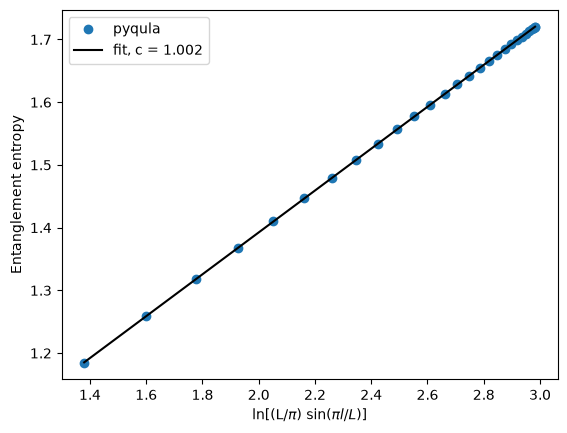

In [3]:
h = geometry.chain().get_hamiltonian(has_spin=False) # spinless chain, half filled
L = 62 # number of unit cells of the ring
ls = range(4,L//2+1) # lengths of the region
ss = [h.get_entanglement_entropy(nsuper=L,region=list(range(l))) for l in ls] # entropies
chord = np.log(L/np.pi*np.sin(np.pi*np.array(ls)/L)) # scaling variable of conformal field theory
(slope,offset) = np.polyfit(chord,ss,1) # linear fit
print("Central charge c =",round(3*slope,4))

plt.plot(chord,ss,marker="o",linestyle="none",label="pyqula")
plt.plot(chord,chord*slope+offset,c="black",label=f"fit, c = {3*slope:.3f}")
plt.xlabel("ln[(L/$\\pi$) sin($\\pi l/L$)]") ; plt.ylabel("Entanglement entropy")
plt.legend()
plt.show()
